In [214]:
import uproot
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy
from scipy.optimize import curve_fit

# Open each file into a separate variable
files = {
    "test": uproot.open("FCCeePostCutCode/run/test.root"),
    "test_noCR": uproot.open("FCCeePostCutCode/run/test_noCR.root")
}

# Example: list the keys from each file
for label, f in files.items():
    print(f"\nHistograms in file: {label}")
    keys = [key.replace(';1','') for key in f.keys()]
    for k in keys:
        print(f"{label}/{k}")


Histograms in file: test
test/Nominal
test/Nominal/counting_WW
test/Nominal/cutFlowHist_WW
test/Nominal/h_W1_truth_mass_WW
test/Nominal/h_W2_truth_mass_WW
test/Nominal/h_W1_truth_p_WW
test/Nominal/h_W2_truth_p_WW
test/Nominal/h_W1_truth_e_WW
test/Nominal/h_W2_truth_e_WW
test/Nominal/h_theta_truth_cs_WW
test/Nominal/h_theta_truth_ud_WW
test/Nominal/h_delta_theta_truth_cs_WW
test/Nominal/h_delta_theta_truth_ud_WW
test/Nominal/h_delta_eta_truth_cs_WW
test/Nominal/h_delta_eta_truth_ud_WW
test/Nominal/h_delta_phi_truth_cs_WW
test/Nominal/h_delta_phi_truth_ud_WW
test/Nominal/h_cos_phi_truth_cs_WW
test/Nominal/h_cos_phi_truth_ud_WW
test/Nominal/h_eec_truth_cs_WW
test/Nominal/h_eec_truth_ud_WW
test/Nominal/h_W1_mass_WW
test/Nominal/h_W2_mass_WW
test/Nominal/h_chi2_WW
test/Nominal/cJet_pt_WW
test/Nominal/lJet0_pt_WW
test/Nominal/lJet1_pt_WW
test/Nominal/lJet2_pt_WW
test/Nominal/cJet_p_WW
test/Nominal/lJet0_p_WW
test/Nominal/lJet1_p_WW
test/Nominal/lJet2_p_WW
test/Nominal/h_W1_p_WW
test/Nominal

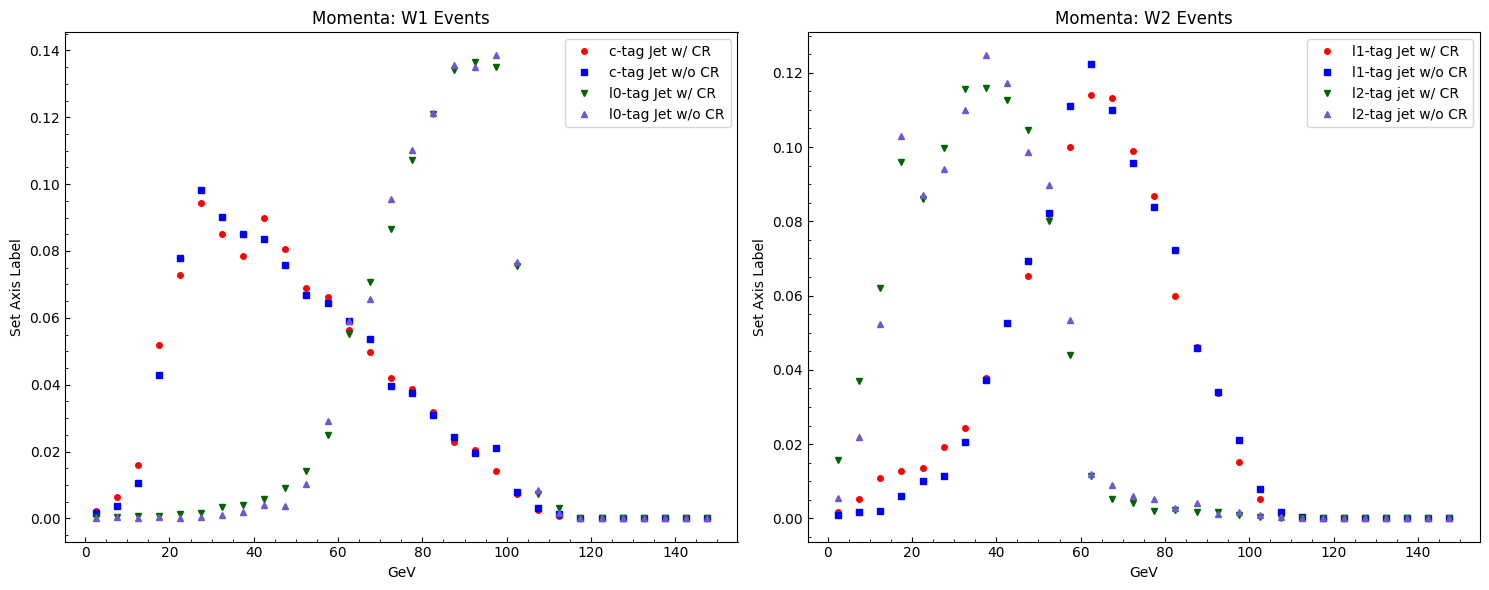

In [162]:
h_cJet_p = files["test"]["Nominal/cJet_p_WW"]
h_cJet_p_noCR = files["test_noCR"]["Nominal/cJet_p_WW"]

h_lJet0_p = files["test"]["Nominal/lJet0_p_WW"]
h_lJet0_p_noCR = files["test_noCR"]["Nominal/lJet0_p_WW"]

h_lJet1_p = files["test"]["Nominal/lJet1_p_WW"]
h_lJet1_p_noCR = files["test_noCR"]["Nominal/lJet1_p_WW"]

h_lJet2_p = files["test"]["Nominal/lJet2_p_WW"]
h_lJet2_p_noCR = files["test_noCR"]["Nominal/lJet2_p_WW"]

values1, edges1 = h_cJet_p.to_numpy()
values2, edges2 = h_cJet_p_noCR.to_numpy()
values3, edges3 = h_lJet0_p.to_numpy()
values4, edges4 = h_lJet0_p_noCR.to_numpy()
values5, edges5 = h_lJet1_p.to_numpy()
values6, edges6 = h_lJet1_p_noCR.to_numpy()
values7, edges7 = h_lJet2_p.to_numpy()
values8, edges8 = h_lJet2_p_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4
values5 = values5 / np.sum(values5) if np.sum(values5) != 0 else values5
values6 = values6 / np.sum(values6) if np.sum(values6) != 0 else values6
values7 = values7 / np.sum(values7) if np.sum(values7) != 0 else values7
values8 = values8 / np.sum(values8) if np.sum(values8) != 0 else values8

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 10  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)
bin_centers5, values5 = rebin(values5, edges5, factor)
bin_centers6, values6 = rebin(values6, edges6, factor)
bin_centers7, values7 = rebin(values7, edges7, factor)
bin_centers8, values8 = rebin(values8, edges8, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='c-tag Jet w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='c-tag Jet w/o CR')
ax1.plot(bin_centers3, values3, marker='v', linestyle='None', color='darkgreen', markersize=4, label='l0-tag Jet w/ CR')
ax1.plot(bin_centers4, values4, marker='^', linestyle='None', color='slateblue', markersize=4, label='l0-tag Jet w/o CR')

ax1.set_xlabel(r'GeV')
ax1.set_ylabel(r'Set Axis Label')
ax1.set_title(r'Momenta: W1 Events')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
# ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
# ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers5, values5, marker='o', linestyle='None', color='red', markersize=4, label='l1-tag Jet w/ CR')
ax2.plot(bin_centers6, values6, marker='s', linestyle='None', color='blue', markersize=4, label='l1-tag jet w/o CR')
ax2.plot(bin_centers7, values7, marker='v', linestyle='None', color='darkgreen', markersize=4, label='l2-tag jet w/ CR')
ax2.plot(bin_centers8, values8, marker='^', linestyle='None', color='slateblue', markersize=4, label='l2-tag jet w/o CR')

ax2.set_xlabel('GeV')
ax2.set_ylabel(r'Set Axis Label')
ax2.set_title(r'Momenta: W2 Events')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
# ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
# ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

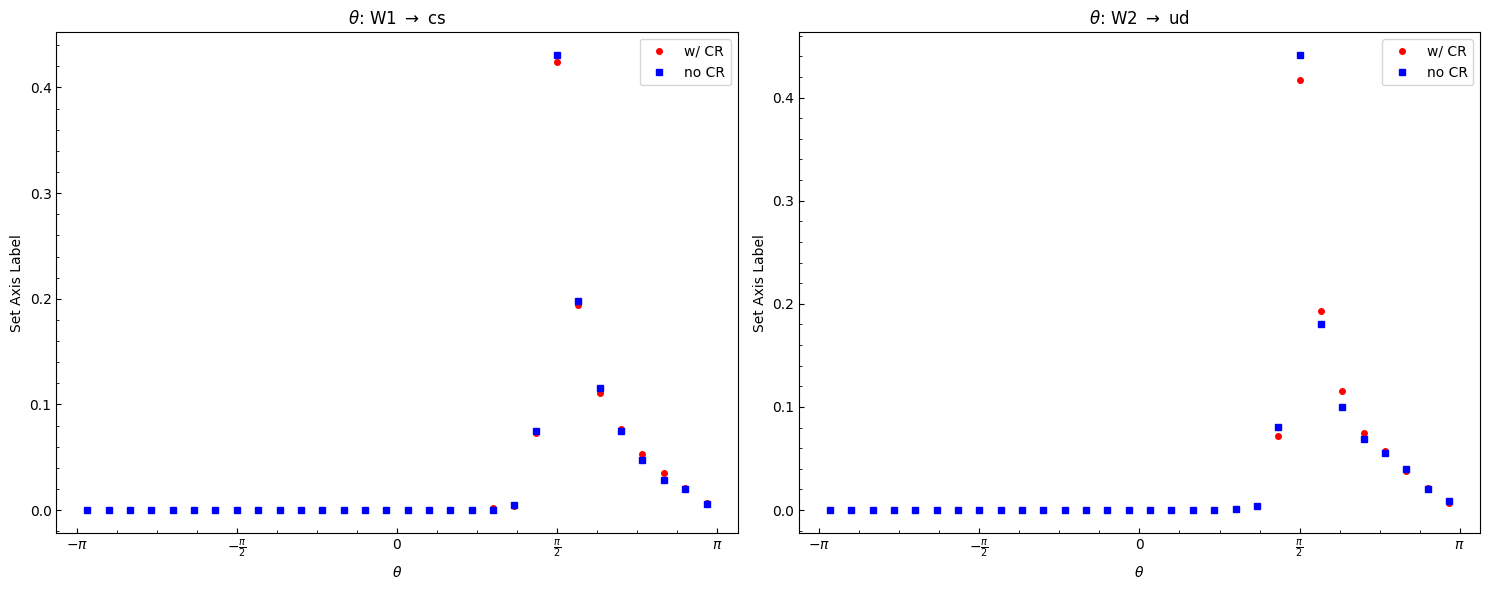

In [163]:
h_theta_cs = files["test"]["Nominal/h_theta_truth_cs_WW"]
h_theta_cs_noCR = files["test_noCR"]["Nominal/h_theta_truth_cs_WW"]

h_theta_ud = files["test"]["Nominal/h_theta_truth_ud_WW"]
h_theta_ud_noCR = files["test_noCR"]["Nominal/h_theta_truth_ud_WW"]

values1, edges1 = h_theta_cs.to_numpy()
values2, edges2 = h_theta_cs_noCR.to_numpy()
values3, edges3 = h_theta_ud.to_numpy()
values4, edges4 = h_theta_ud_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'Set Axis Label')
ax1.set_title(r'$\theta$: W1 $\rightarrow$ cs')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel(r'Set Axis Label')
ax2.set_title(r'$\theta$: W2 $\rightarrow$ ud')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

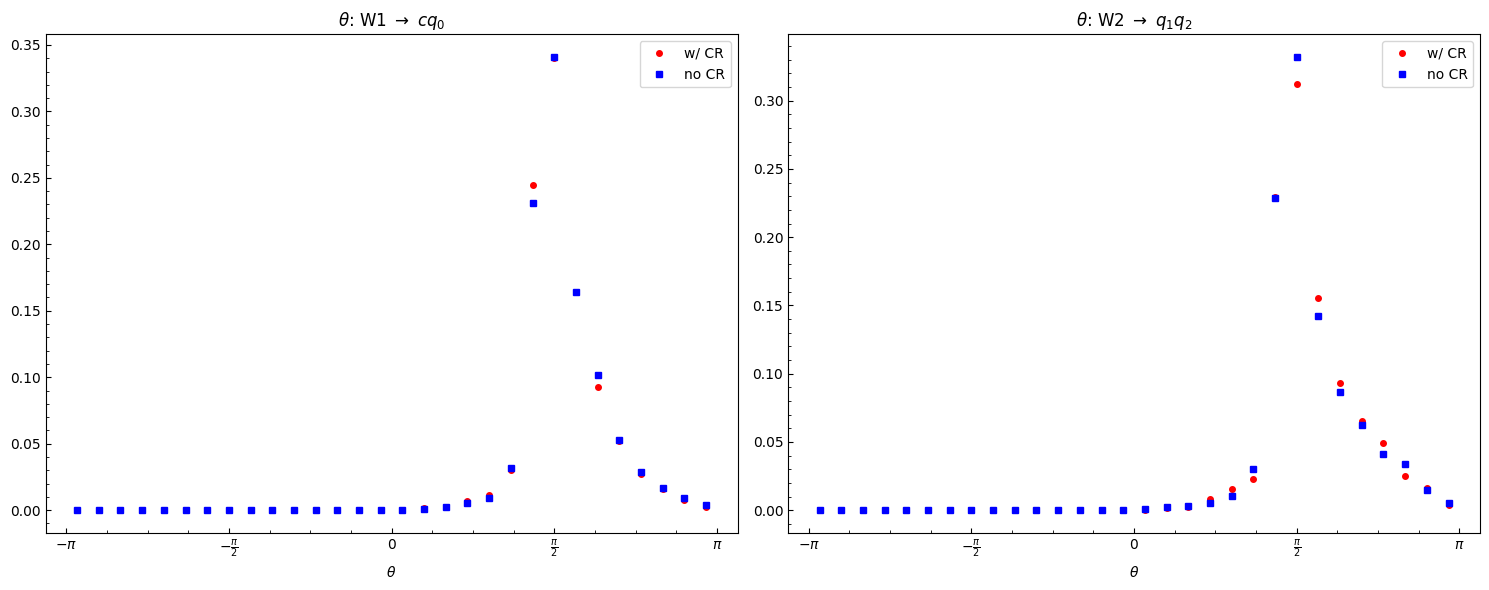

In [123]:
h_theta_c_l0 = files["test"]["Nominal/h_theta_c_l0_WW"]
h_theta_c_l0_noCR = files["test_noCR"]["Nominal/h_theta_c_l0_WW"]

h_theta_l1_l2 = files["test"]["Nominal/h_theta_l1_l2_WW"]
h_theta_l1_l2_noCR = files["test_noCR"]["Nominal/h_theta_l1_l2_WW"]

values1, edges1 = h_theta_c_l0.to_numpy()
values2, edges2 = h_theta_c_l0_noCR.to_numpy()
values3, edges3 = h_theta_l1_l2.to_numpy()
values4, edges4 = h_theta_l1_l2_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\theta$')
ax1.set_title(r'$\theta$: W1 $\rightarrow$ $cq_0$')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\theta$')
ax2.set_title(r'$\theta$: W2 $\rightarrow$ $q_1q_2$')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

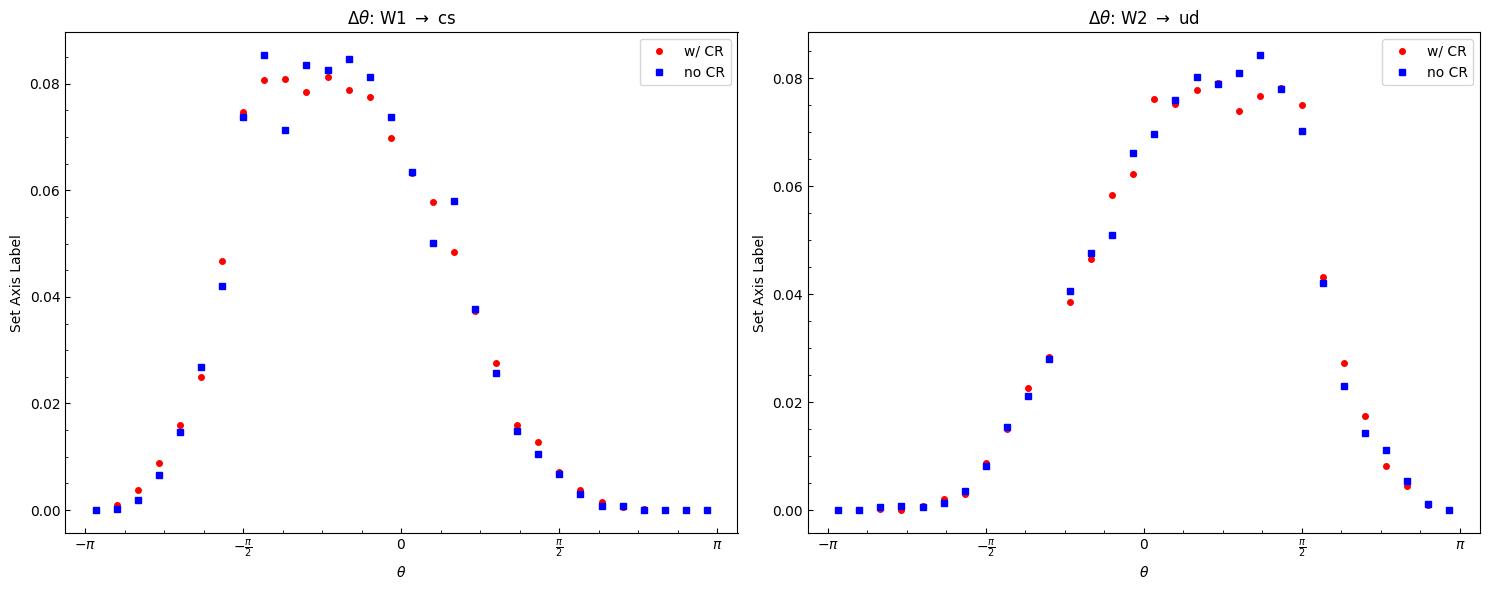

In [164]:
h_delta_theta_cs = files["test"]["Nominal/h_delta_theta_truth_cs_WW"]
h_delta_theta_cs_noCR = files["test_noCR"]["Nominal/h_delta_theta_truth_cs_WW"]

h_delta_theta_ud = files["test"]["Nominal/h_delta_theta_truth_ud_WW"]
h_delta_theta_ud_noCR = files["test_noCR"]["Nominal/h_delta_theta_truth_ud_WW"]

values1, edges1 = h_delta_theta_cs.to_numpy()
values2, edges2 = h_delta_theta_cs_noCR.to_numpy()
values3, edges3 = h_delta_theta_ud.to_numpy()
values4, edges4 = h_delta_theta_ud_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'Set Axis Label')
ax1.set_title(r'$\Delta\theta$: W1 $\rightarrow$ cs')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel(r'Set Axis Label')
ax2.set_title(r'$\Delta\theta$: W2 $\rightarrow$ ud')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

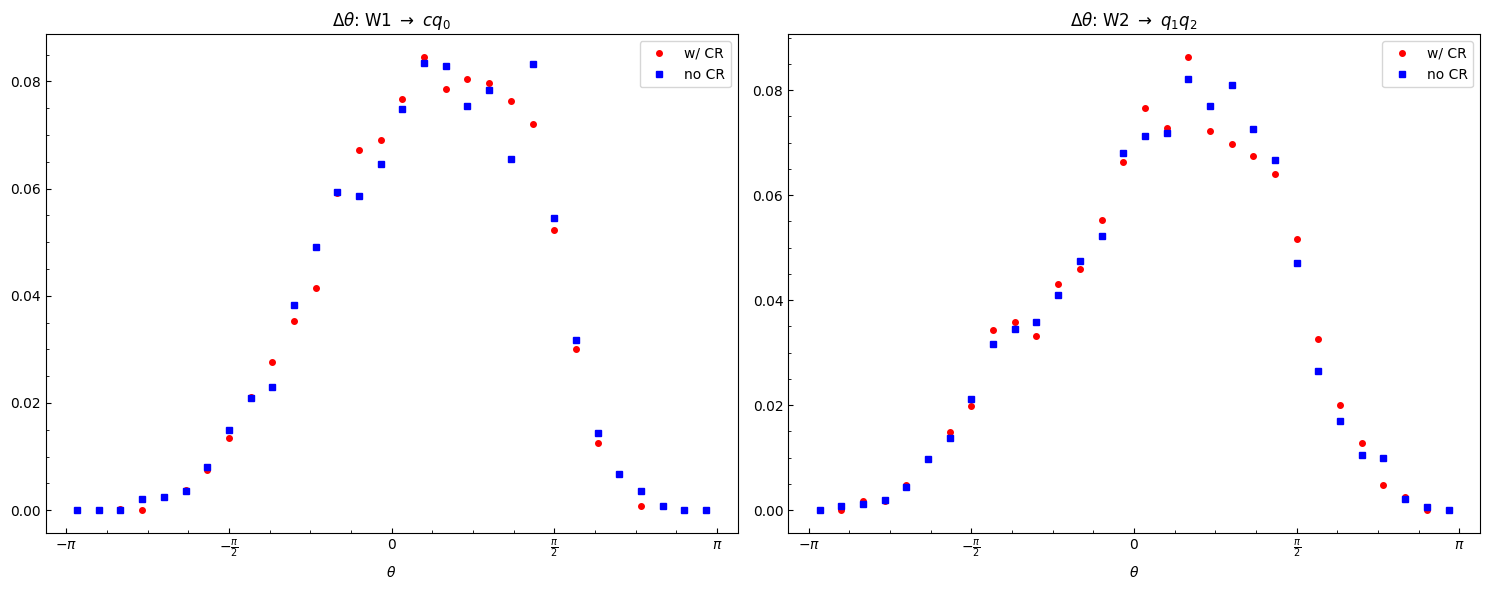

In [121]:
h_delta_theta_c_l0 = files["test"]["Nominal/h_delta_theta_c_l0_WW"]
h_delta_theta_c_l0_noCR = files["test_noCR"]["Nominal/h_delta_theta_c_l0_WW"]

h_delta_theta_l1_l2 = files["test"]["Nominal/h_delta_theta_l1_l2_WW"]
h_delta_theta_l1_l2_noCR = files["test_noCR"]["Nominal/h_delta_theta_l1_l2_WW"]

values1, edges1 = h_delta_theta_c_l0.to_numpy()
values2, edges2 = h_delta_theta_c_l0_noCR.to_numpy()
values3, edges3 = h_delta_theta_l1_l2.to_numpy()
values4, edges4 = h_delta_theta_l1_l2_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\theta$')
ax1.set_title(r'$\Delta\theta$: W1 $\rightarrow$ $cq_0$')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\theta$')
ax2.set_title(r'$\Delta\theta$: W2 $\rightarrow$ $q_1q_2$')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

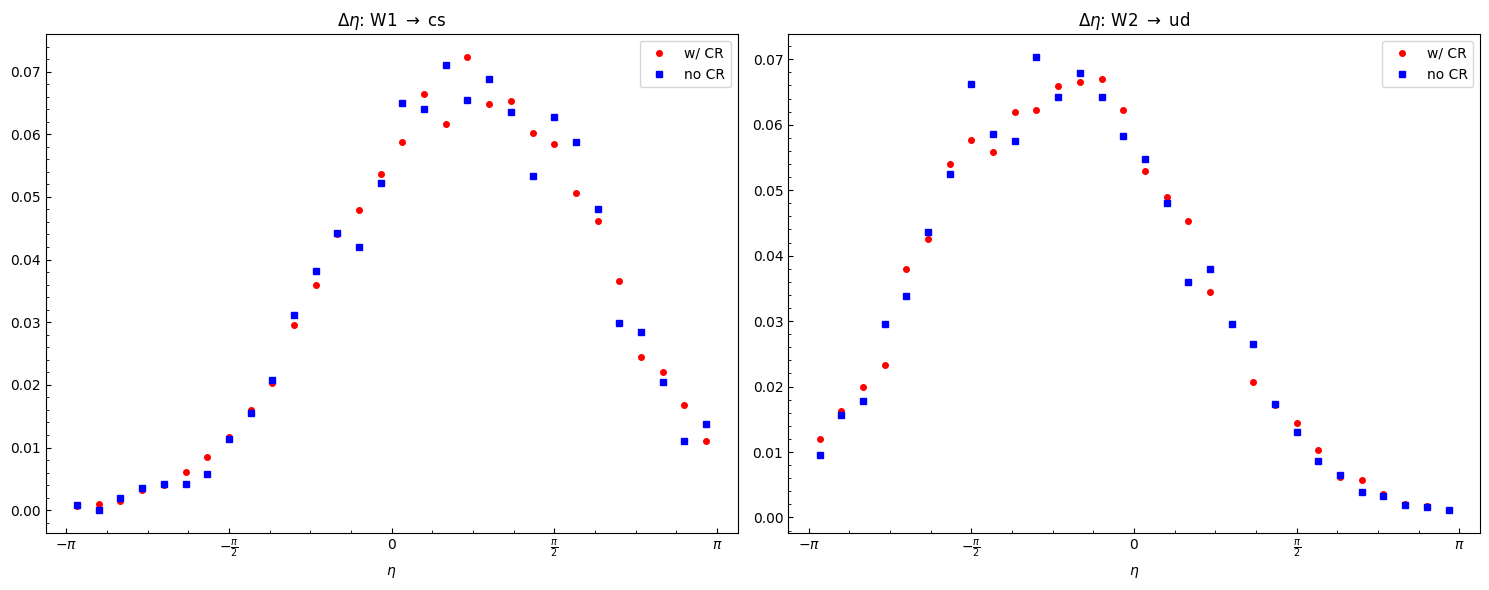

In [165]:
h_delta_eta_cs = files["test"]["Nominal/h_delta_eta_truth_cs_WW"]
h_delta_eta_cs_noCR = files["test_noCR"]["Nominal/h_delta_eta_truth_cs_WW"]

h_delta_eta_ud = files["test"]["Nominal/h_delta_eta_truth_ud_WW"]
h_delta_eta_ud_noCR = files["test_noCR"]["Nominal/h_delta_eta_truth_ud_WW"]

values1, edges1 = h_delta_eta_cs.to_numpy()
values2, edges2 = h_delta_eta_cs_noCR.to_numpy()
values3, edges3 = h_delta_eta_ud.to_numpy()
values4, edges4 = h_delta_eta_ud_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\eta$')
ax1.set_title(r'$\Delta\eta$: W1 $\rightarrow$ cs')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\eta$')
ax2.set_title(r'$\Delta\eta$: W2 $\rightarrow$ ud')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

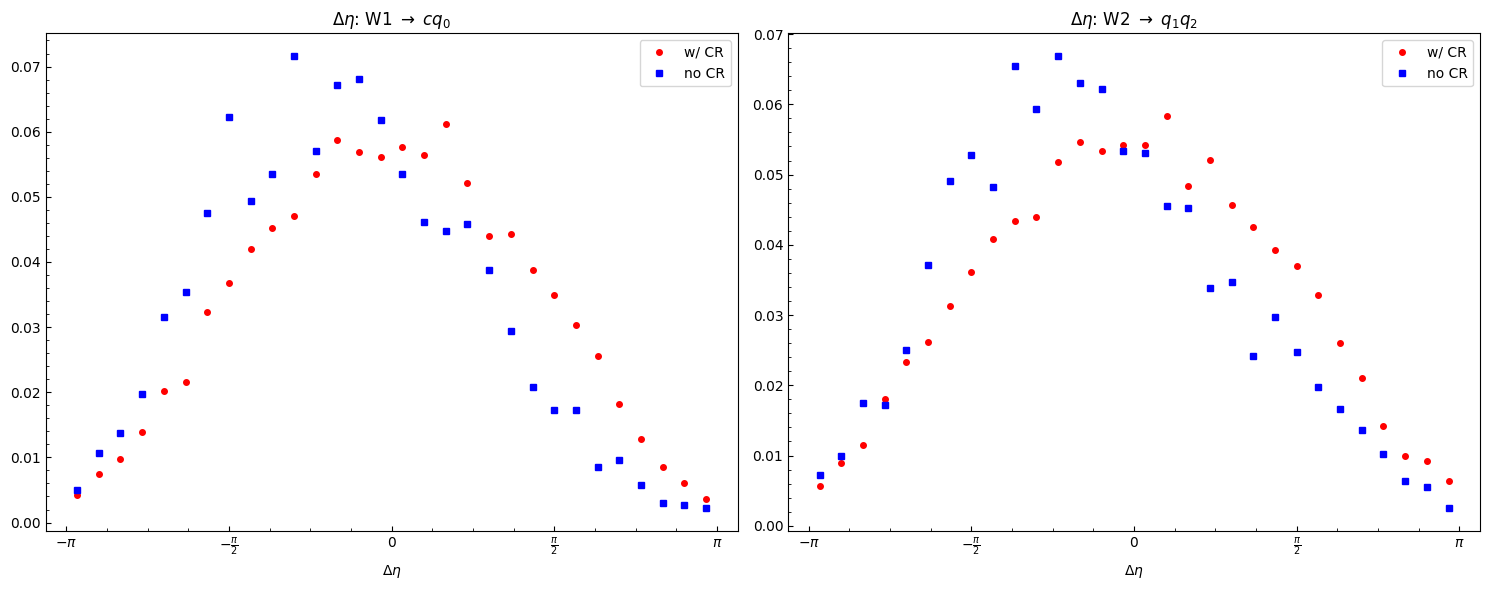

In [166]:
h_delta_eta_c_l0 = files["test"]["Nominal/h_delta_eta_c_l0_WW"]
h_delta_eta_c_l0_noCR = files["test_noCR"]["Nominal/h_delta_eta_c_l0_WW"]

h_delta_eta_l1_l2 = files["test"]["Nominal/h_delta_eta_l1_l2_WW"]
h_delta_eta_l1_l2_noCR = files["test_noCR"]["Nominal/h_delta_eta_l1_l2_WW"]

values1, edges1 = h_delta_eta_c_l0.to_numpy()
values2, edges2 = h_delta_eta_c_l0_noCR.to_numpy()
values3, edges3 = h_delta_eta_l1_l2.to_numpy()
values4, edges4 = h_delta_eta_l1_l2_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\Delta\eta$')
ax1.set_title(r'$\Delta\eta$: W1 $\rightarrow$ $cq_0$')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\Delta\eta$')
ax2.set_title(r'$\Delta\eta$: W2 $\rightarrow$ $q_1q_2$')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

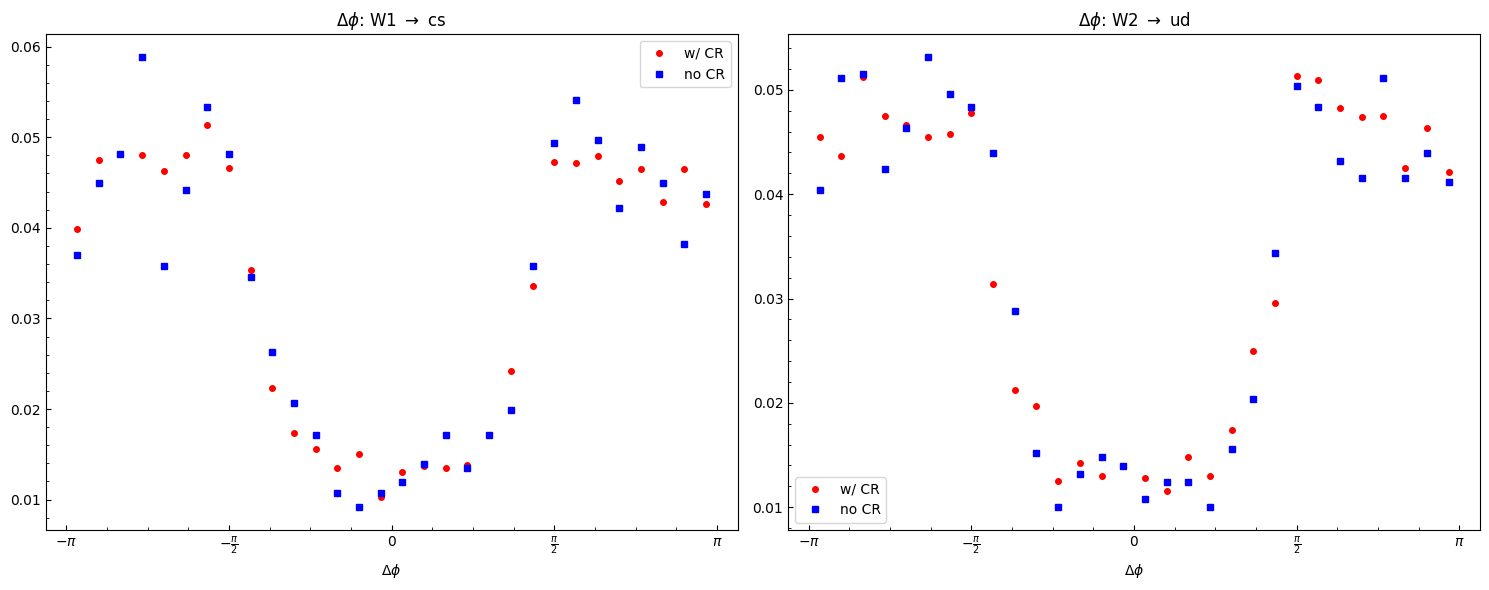

In [167]:
h_delta_phi_cs = files["test"]["Nominal/h_delta_phi_truth_cs_WW"]
h_delta_phi_cs_noCR = files["test_noCR"]["Nominal/h_delta_phi_truth_cs_WW"]

h_delta_phi_ud = files["test"]["Nominal/h_delta_phi_truth_ud_WW"]
h_delta_phi_ud_noCR = files["test_noCR"]["Nominal/h_delta_phi_truth_ud_WW"]

values1, edges1 = h_delta_phi_cs.to_numpy()
values2, edges2 = h_delta_phi_cs_noCR.to_numpy()
values3, edges3 = h_delta_phi_ud.to_numpy()
values4, edges4 = h_delta_phi_ud_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\Delta\phi$')
ax1.set_title(r'$\Delta\phi$: W1 $\rightarrow$ cs')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\Delta\phi$')
ax2.set_title(r'$\Delta\phi$: W2 $\rightarrow$ ud')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

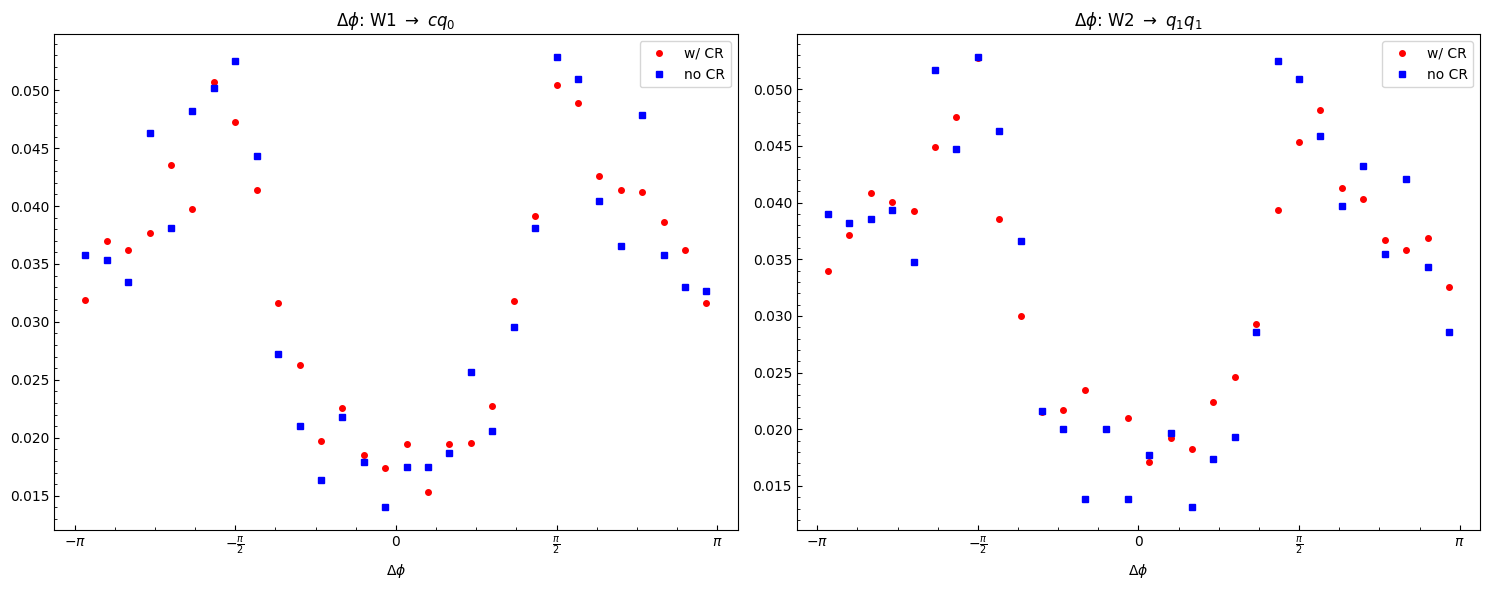

In [168]:
h_delta_phi_c_l0 = files["test"]["Nominal/h_delta_phi_c_l0_WW"]
h_delta_phi_c_l0_noCR = files["test_noCR"]["Nominal/h_delta_phi_c_l0_WW"]

h_delta_phi_l1_l2 = files["test"]["Nominal/h_delta_phi_l1_l2_WW"]
h_delta_phi_l1_l2_noCR = files["test_noCR"]["Nominal/h_delta_phi_l1_l2_WW"]

values1, edges1 = h_delta_phi_c_l0.to_numpy()
values2, edges2 = h_delta_phi_c_l0_noCR.to_numpy()
values3, edges3 = h_delta_phi_l1_l2.to_numpy()
values4, edges4 = h_delta_phi_l1_l2_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\Delta\phi$')
ax1.set_title(r'$\Delta\phi$: W1 $\rightarrow$ $cq_0$')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax1.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\Delta\phi$')
ax2.set_title(r'$\Delta\phi$: W2 $\rightarrow$ $q_1q_1$')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()
ax2.set_xticks(np.arange(-np.pi, np.pi + 0.1, np.pi / 2))
ax2.set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])

plt.tight_layout()
plt.show()

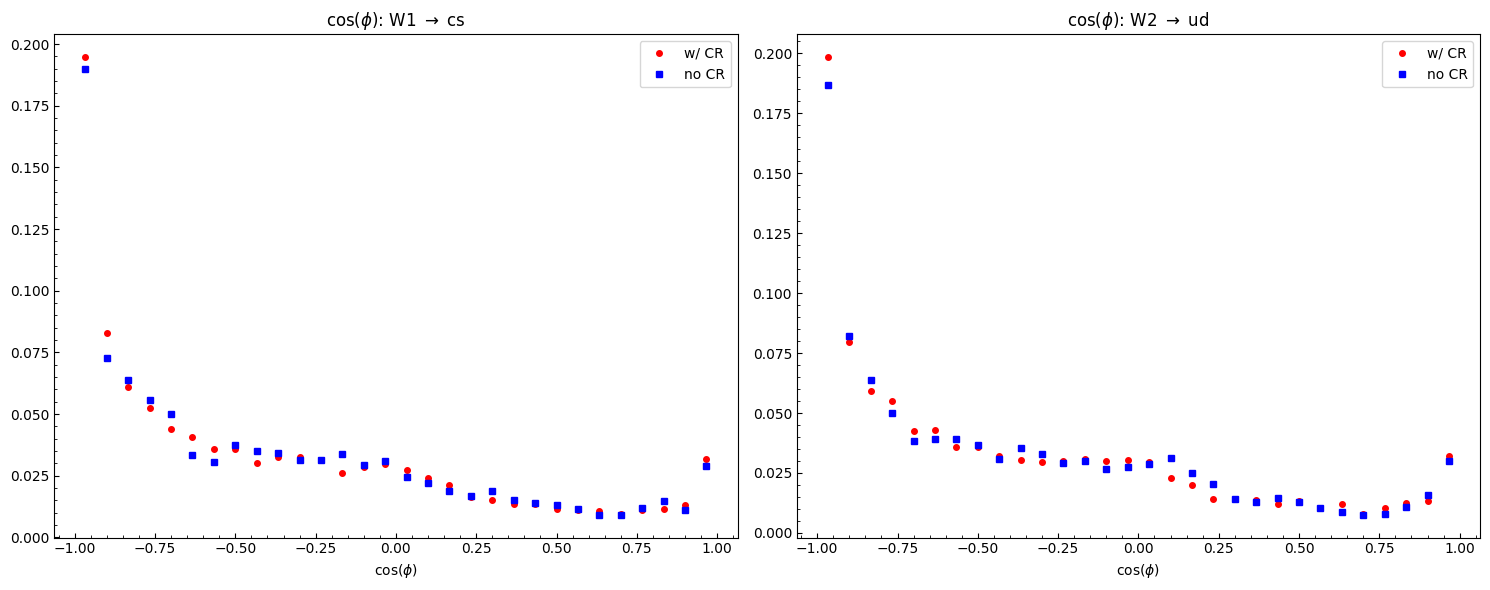

In [169]:
h_cos_phi_cs = files["test"]["Nominal/h_cos_phi_truth_cs_WW"]
h_cos_phi_cs_noCR = files["test_noCR"]["Nominal/h_cos_phi_truth_cs_WW"]

h_cos_phi_ud = files["test"]["Nominal/h_cos_phi_truth_ud_WW"]
h_cos_phi_ud_noCR = files["test_noCR"]["Nominal/h_cos_phi_truth_ud_WW"]

values1, edges1 = h_cos_phi_cs.to_numpy()
values2, edges2 = h_cos_phi_cs_noCR.to_numpy()
values3, edges3 = h_cos_phi_ud.to_numpy()
values4, edges4 = h_cos_phi_ud_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\cos(\phi)$')
ax1.set_title(r'$\cos(\phi)$: W1 $\rightarrow$ cs')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\cos(\phi)$')
ax2.set_title(r'$\cos(\phi)$: W2 $\rightarrow$ ud')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()

plt.tight_layout()
plt.show()

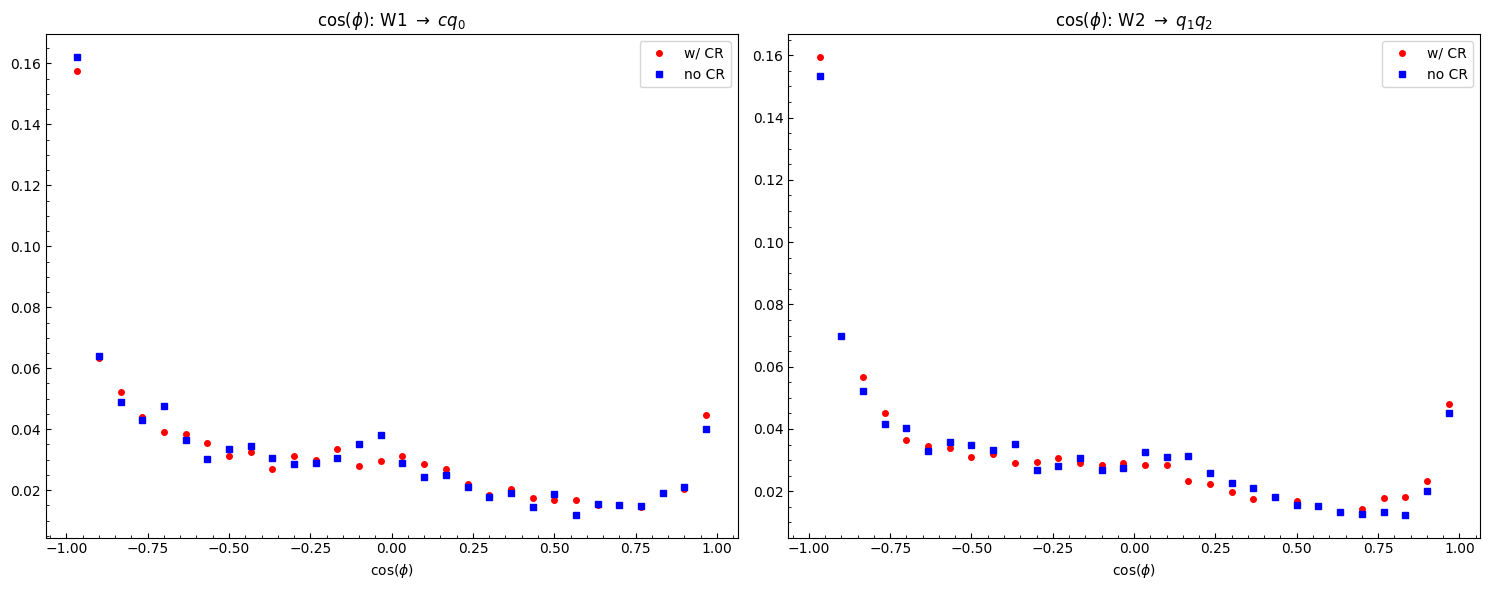

In [170]:
h_cos_phi_c_l0 = files["test"]["Nominal/h_cos_phi_c_l0_WW"]
h_cos_phi_c_l0_noCR = files["test_noCR"]["Nominal/h_cos_phi_c_l0_WW"]

h_cos_phi_l1_l2 = files["test"]["Nominal/h_cos_phi_l1_l2_WW"]
h_cos_phi_l1_l2_noCR = files["test_noCR"]["Nominal/h_cos_phi_l1_l2_WW"]

values1, edges1 = h_cos_phi_c_l0.to_numpy()
values2, edges2 = h_cos_phi_c_l0_noCR.to_numpy()
values3, edges3 = h_cos_phi_l1_l2.to_numpy()
values4, edges4 = h_cos_phi_l1_l2_noCR.to_numpy()

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2
values3 = values3 / np.sum(values3) if np.sum(values3) != 0 else values3
values4 = values4 / np.sum(values4) if np.sum(values4) != 0 else values4

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)
bin_centers3, values3 = rebin(values3, edges3, factor)
bin_centers4, values4 = rebin(values4, edges4, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# === Pad 1: W1 ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.set_xlabel(r'$\cos(\phi)$')
ax1.set_title(r'$\cos(\phi)$: W1 $\rightarrow$ $cq_0$')
ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()

# === Pad 2: W2 ===
ax2.plot(bin_centers3, values3, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax2.plot(bin_centers4, values4, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax2.set_xlabel(r'$\cos(\phi)$')
ax2.set_title(r'$\cos(\phi)$: W2 $\rightarrow$ $q_1q_2$')
ax2.legend()
ax2.tick_params(axis='both', which='both', direction='in')
ax2.minorticks_on()

plt.tight_layout()
plt.show()

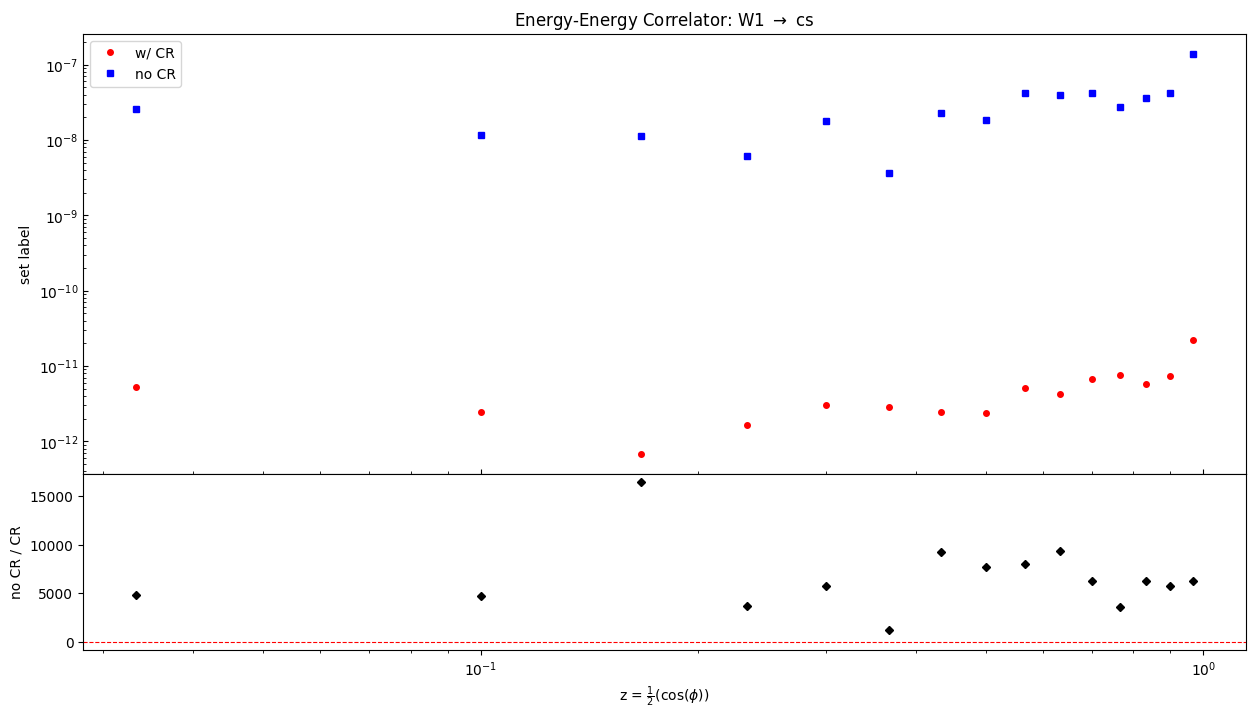

In [215]:
h_eec_truth_cs = files["test"]["Nominal/h_eec_truth_cs_WW"]
h_eec_truth_cs_noCR = files["test_noCR"]["Nominal/h_eec_truth_cs_WW"]

xsection_CR = 16.4385
xsection_noCR = 100000 # Placeholder value

nEvents = 100000

scale_CR = xsection_CR / nEvents
scale_noCR = xsection_noCR / nEvents

# Convert to numpy arrays
values1, edges1 = h_eec_truth_cs.to_numpy()
values2, edges2 = h_eec_truth_cs_noCR.to_numpy()

values1 = values1 * scale_CR
values2 = values2 * scale_noCR

# values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
# values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})
plt.subplots_adjust(hspace=0)

# === Pad 1: Angular Distributions ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_ylabel('set label')
ax1.set_title(r'Energy-Energy Correlator: W1 $\rightarrow$ cs')
ax1.set_xscale('log')
ax1.set_yscale('log')

# === Pad 2: Ratios ===
def safe_divide(num, denom):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.true_divide(num, denom)
        ratio[~np.isfinite(ratio)] = 0  # -inf, inf, NaN -> 0 or np.nan as you prefer
    return ratio

ratio1 = safe_divide(values2, values1)

ax2.plot(bin_centers1, ratio1, marker='D', linestyle='None', color='black', markersize=4)
ax2.axhline(y=1, color='r', linestyle='--', linewidth = 0.8)

ax2.set_xlabel(r'z = $\frac{1}{2}(\cos(\phi))$')
ax2.set_ylabel('no CR / CR')
ax2.set_xscale('log')
ax2.set_yscale('linear')

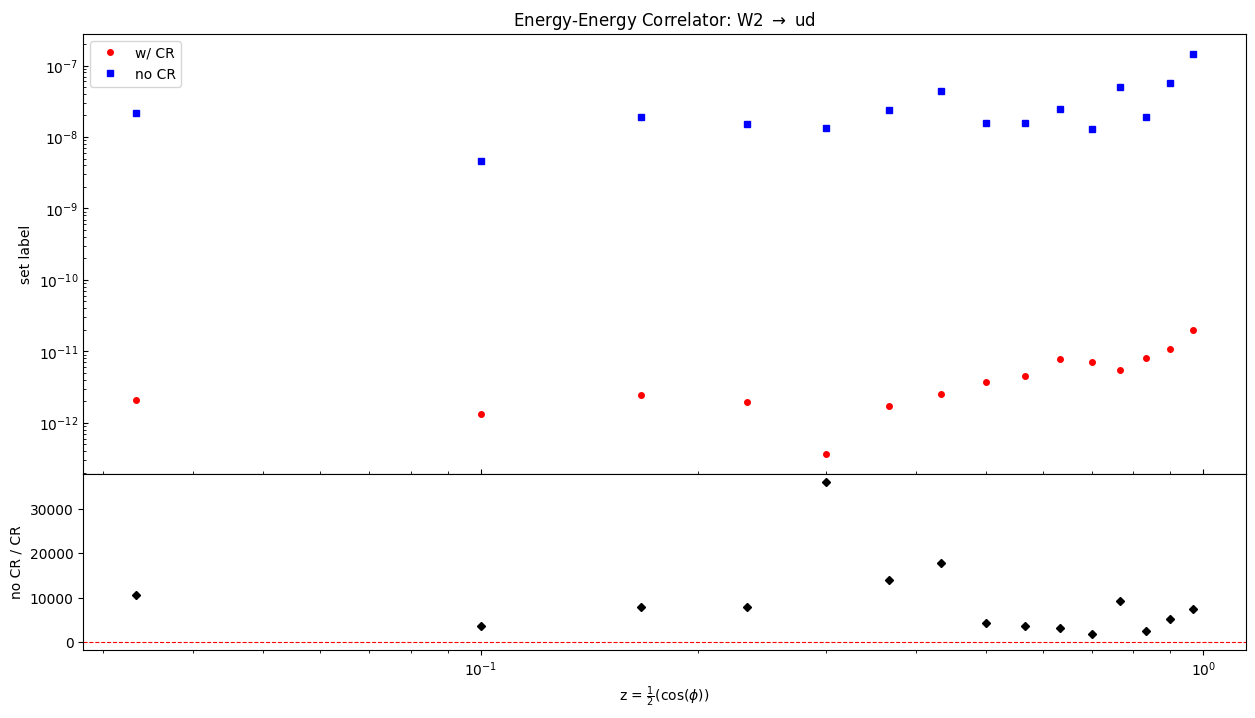

In [216]:
h_eec_truth_ud = files["test"]["Nominal/h_eec_truth_ud_WW"]
h_eec_truth_ud_noCR = files["test_noCR"]["Nominal/h_eec_truth_ud_WW"]

xsection_CR = 16.4385
xsection_noCR = 100000 # Placeholder value

nEvents = 100000

scale_CR = xsection_CR / nEvents
scale_noCR = xsection_noCR / nEvents

# Convert to numpy arrays
values1, edges1 = h_eec_truth_ud.to_numpy()
values2, edges2 = h_eec_truth_ud_noCR.to_numpy()

values1 = values1 * scale_CR
values2 = values2 * scale_noCR

# values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
# values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})
plt.subplots_adjust(hspace=0)

# === Pad 1: Angular Distributions ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_ylabel('set label')
ax1.set_title(r'Energy-Energy Correlator: W2 $\rightarrow$ ud')
ax1.set_xscale('log')
ax1.set_yscale('log')

# === Pad 2: Ratios ===
def safe_divide(num, denom):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.true_divide(num, denom)
        ratio[~np.isfinite(ratio)] = 0  # -inf, inf, NaN -> 0 or np.nan as you prefer
    return ratio

ratio1 = safe_divide(values2, values1)

ax2.plot(bin_centers1, ratio1, marker='D', linestyle='None', color='black', markersize=4)
ax2.axhline(y=1, color='r', linestyle='--', linewidth = 0.8)

# ax2.legend()
ax2.set_xlabel(r'z = $\frac{1}{2}(\cos(\phi))$')
ax2.set_ylabel('no CR / CR')
ax2.set_xscale('log')
ax2.set_yscale('linear')
# ax2.set_ylim(0.85, 1.1)

(0.85, 1.1)

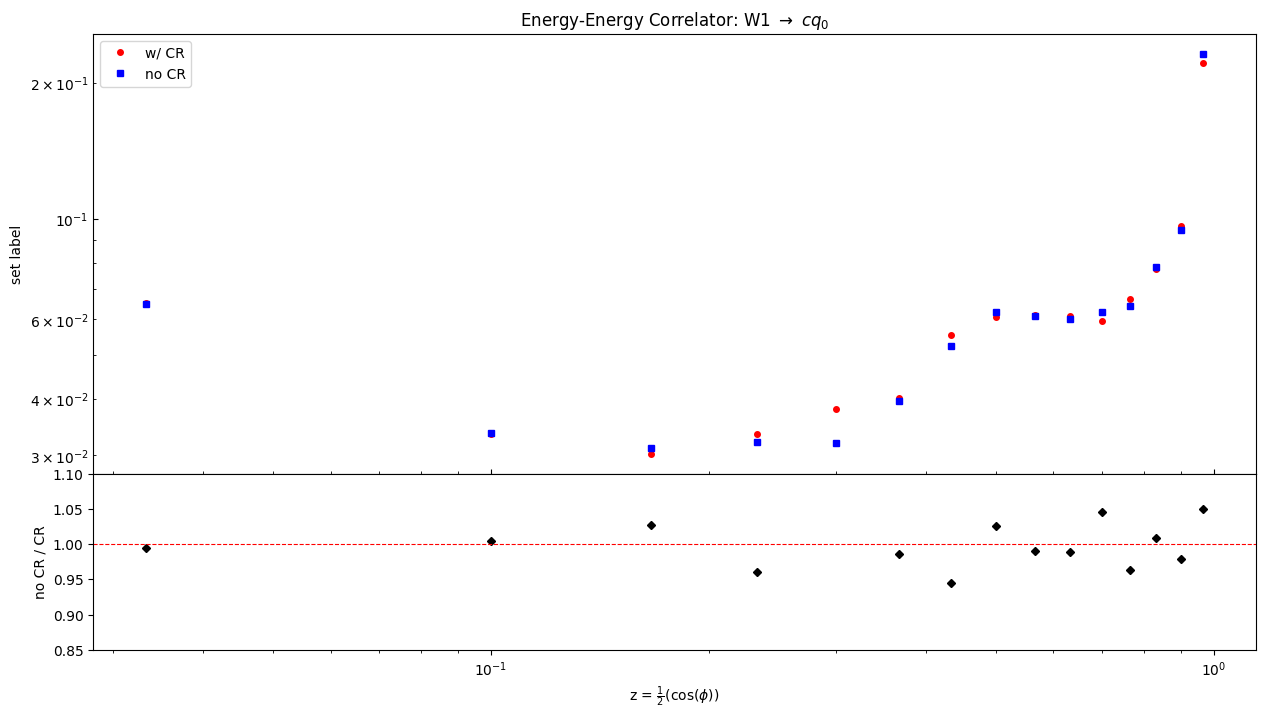

In [222]:
h_eec_c_l0 = files["test"]["Nominal/h_eec_c_l0_WW"]
h_eec_c_l0_noCR = files["test_noCR"]["Nominal/h_eec_c_l0_WW"]

xsection_CR = 16.4385
xsection_noCR = 10 # Placeholder value

nEvents = 100000

scale_CR = xsection_CR / nEvents
scale_noCR = xsection_noCR / nEvents

# Convert to numpy arrays
values1, edges1 = h_eec_c_l0.to_numpy()
values2, edges2 = h_eec_c_l0_noCR.to_numpy()

values1 = values1 * scale_CR
values2 = values2 * scale_noCR

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})
plt.subplots_adjust(hspace=0)

# === Pad 1: Angular Distributions ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_ylabel('set label')
ax1.set_title(r'Energy-Energy Correlator: W1 $\rightarrow$ $cq_0$')
ax1.set_xscale('log')
ax1.set_yscale('log')

# === Pad 2: Ratios ===
def safe_divide(num, denom):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.true_divide(num, denom)
        ratio[~np.isfinite(ratio)] = 0  # -inf, inf, NaN -> 0 or np.nan as you prefer
    return ratio

ratio1 = safe_divide(values2, values1)

ax2.plot(bin_centers1, ratio1, marker='D', linestyle='None', color='black', markersize=4)
ax2.axhline(y=1, color='r', linestyle='--', linewidth = 0.8)

# ax2.legend()
ax2.set_xlabel(r'z = $\frac{1}{2}(\cos(\phi))$')
ax2.set_ylabel('no CR / CR')
ax2.set_xscale('log')
ax2.set_yscale('linear')
ax2.set_ylim(0.85, 1.1)

(0.85, 1.1)

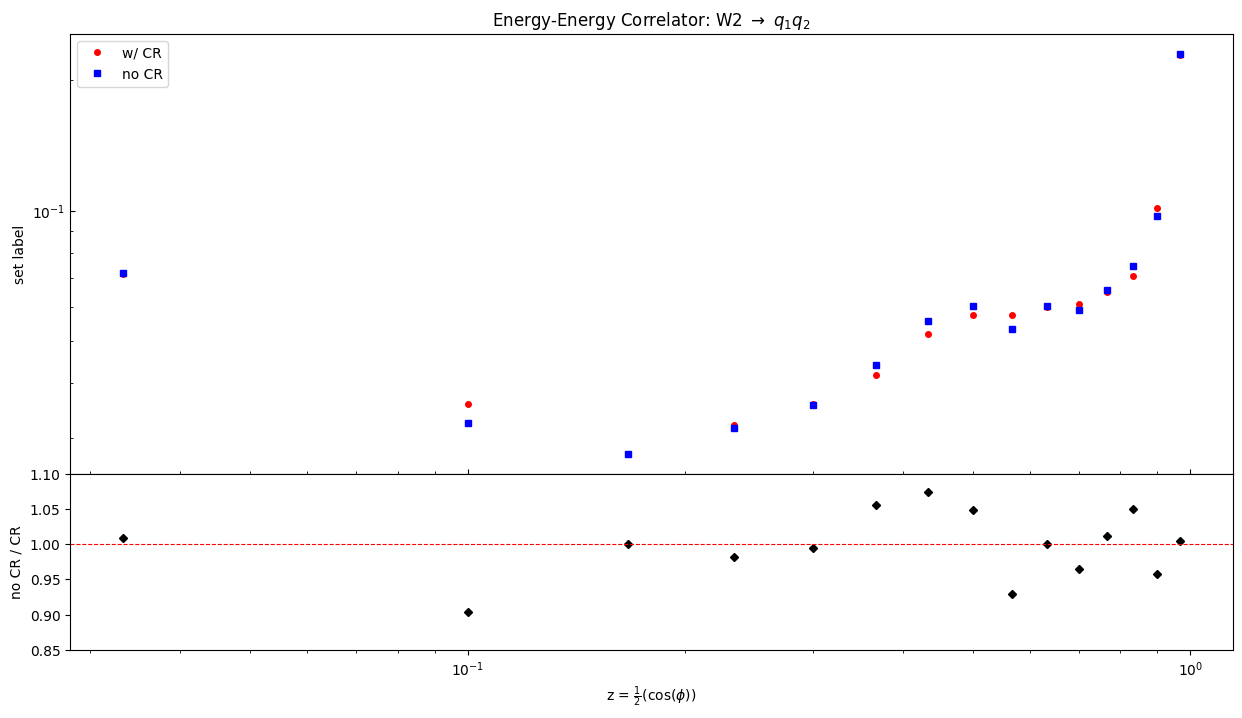

In [223]:
h_eec_l1_l2 = files["test"]["Nominal/h_eec_l1_l2_WW"]
h_eec_l1_l2_noCR = files["test_noCR"]["Nominal/h_eec_l1_l2_WW"]

xsection_CR = 16.4385
xsection_noCR = 10 # Placeholder value

nEvents = 100000

scale_CR = xsection_CR / nEvents
scale_noCR = xsection_noCR / nEvents

# Convert to numpy arrays
values1, edges1 = h_eec_l1_l2.to_numpy()
values2, edges2 = h_eec_l1_l2_noCR.to_numpy()

values1 = values1 * scale_CR
values2 = values2 * scale_noCR

values1 = values1 / np.sum(values1) if np.sum(values1) != 0 else values1
values2 = values2 / np.sum(values2) if np.sum(values2) != 0 else values2

def rebin(values, edges, factor):
    assert len(values) % factor == 0, "Number of bins must be divisible by rebin factor."
    
    rebinned_values = values.reshape(-1, factor).sum(axis=1)
    rebinned_edges = edges[::factor]
    rebinned_centers = (rebinned_edges[:-1] + rebinned_edges[1:]) / 2

    return rebinned_centers, rebinned_values

factor = 5  # change this as needed

bin_centers1, values1 = rebin(values1, edges1, factor)
bin_centers2, values2 = rebin(values2, edges2, factor)

# Create figure with two pads (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})
plt.subplots_adjust(hspace=0)

# === Pad 1: Angular Distributions ===
ax1.plot(bin_centers1, values1, marker='o', linestyle='None', color='red', markersize=4, label='w/ CR')
ax1.plot(bin_centers2, values2, marker='s', linestyle='None', color='blue', markersize=4, label='no CR')

ax1.legend()
ax1.tick_params(axis='both', which='both', direction='in')
ax1.minorticks_on()
ax1.set_ylabel('set label')
ax1.set_title(r'Energy-Energy Correlator: W2 $\rightarrow$ $q_1q_2$')
ax1.set_xscale('log')
ax1.set_yscale('log')

# === Pad 2: Ratios ===
def safe_divide(num, denom):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.true_divide(num, denom)
        ratio[~np.isfinite(ratio)] = 0  # -inf, inf, NaN -> 0 or np.nan as you prefer
    return ratio

ratio1 = safe_divide(values2, values1)

ax2.plot(bin_centers1, ratio1, marker='D', linestyle='None', color='black', markersize=4)
ax2.axhline(y=1, color='r', linestyle='--', linewidth = 0.8)

# ax2.legend()
ax2.set_xlabel(r'z = $\frac{1}{2}(\cos(\phi))$')
ax2.set_ylabel('no CR / CR')
ax2.set_xscale('log')
ax2.set_yscale('linear')
ax2.set_ylim(0.85, 1.1)